In [1]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [2]:
import sys, os

# __file__ doesn't exist in notebooks, so derive path from the known notebook location
notebooks_dir = os.path.join(os.path.abspath('.'), 'notebooks')
sys.path.insert(0, notebooks_dir)

from utils.sampling import load_or_sample


df = load_or_sample(
    filepath="/home/ishola/codetopia/mga/raw-data/openfoodfacts.csv",
    output_csv="/home/ishola/codetopia/mga/raw-data/openfoodfacts_sample.csv",
    output_meta="/home/ishola/codetopia/mga/raw-data/openfoodfacts_sample_meta.json",
    sample_size=2_500_000,
    seed=42,
    chunk_size=25_000,
)

✅ Cached sample found — loading from disk.
   Shape: (2500000, 135)
   🧠 Memory: 4149 MB


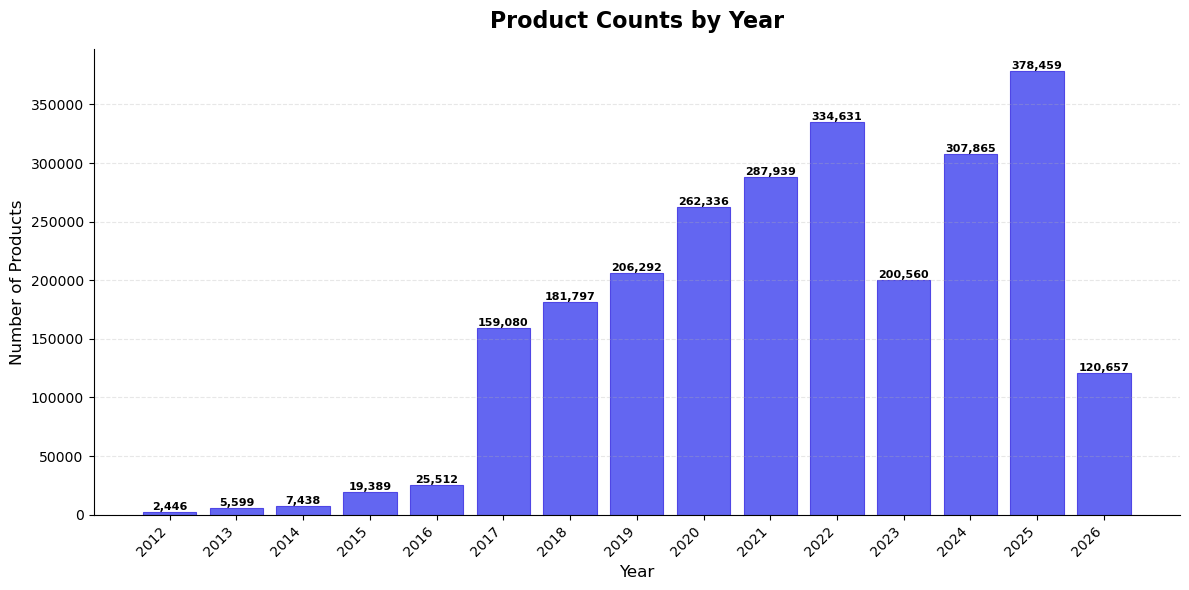

In [3]:

df['created_datetime'] = pd.to_datetime(df['created_datetime'], errors='coerce')

yearly_counts = df['created_datetime'].dt.year.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(yearly_counts.index.astype(int), yearly_counts.values,
              color='#6366f1', edgecolor='#4f46e5', linewidth=0.8)

# Annotate bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height,
            f'{int(height):,}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_title('Product Counts by Year', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Products', fontsize=12)
ax.set_xticks(yearly_counts.index.astype(int))
ax.set_xticklabels(yearly_counts.index.astype(int), rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500000 entries, 0 to 2499999
Columns: 135 entries, code to water_100g
dtypes: datetime64[ns, UTC](1), float64(123), object(11)
memory usage: 2.5+ GB


In [5]:
# 1. Calculate missing ratio for each column
missing_ratio = df.isnull().mean()

# 2. Print columns and their missing ratios
print("Missing Ratios per Column:")
print(missing_ratio)

# 3. Identify columns with <= 80% missingness (keep these)
cols_to_keep = missing_ratio[missing_ratio <= 0.80].index


print(f'\nColumns to keep: \n {cols_to_keep}')
# 4. Filter the DataFrame
df_without_missing = df[cols_to_keep]

# # Optional: Verify the new shape
print(f"\nCount of columns to keep: {df_without_missing.shape[1]}")

Missing Ratios per Column:
code                        0.000000
created_datetime            0.000000
product_name                0.074927
brands_tags                 0.372324
categories_tags             0.589096
                              ...   
sulphate_100g               0.999870
nitrate_100g                0.999916
acidity_100g                0.999992
carbohydrates-total_100g    0.999704
water_100g                  0.946523
Length: 135, dtype: float64

Columns to keep: 
 Index(['code', 'created_datetime', 'product_name', 'brands_tags',
       'categories_tags', 'labels_tags', 'countries_tags', 'ingredients_tags',
       'ingredients_analysis_tags', 'nova_group', 'main_category_en',
       'energy-kj_100g', 'energy-kcal_100g', 'energy_100g', 'fat_100g',
       'saturated-fat_100g', 'carbohydrates_100g', 'sugars_100g', 'fiber_100g',
       'proteins_100g', 'salt_100g', 'sodium_100g'],
      dtype='object')

Count of columns to keep: 22


In [6]:
# Dropping columns with 0 variance

# 1. Identify numeric columns with 0 variance
numeric_cols = df_without_missing.select_dtypes(include=['number']).columns
zero_var_numeric = [col for col in numeric_cols if df_without_missing[col].var() == 0]

# 2. Identify categorical columns with only 1 unique value
categorical_cols = df_without_missing.select_dtypes(exclude=['number']).columns
zero_var_categorical = [col for col in categorical_cols if df_without_missing[col].nunique() == 1]

# 3. Drop both sets
cols_to_drop = zero_var_numeric + zero_var_categorical
df_with_variance = df_without_missing.drop(columns=cols_to_drop)

print(f"Dropped {len(cols_to_drop)} zero-variance columns: {cols_to_drop}")
print(f"Remaining shape: {df_without_missing.shape}")


Dropped 0 zero-variance columns: []
Remaining shape: (2500000, 22)


In [7]:
# ── Domain-aware redundancy removal 
safe_to_drop = [
    'energy_100g',      # duplicate of energy-kj_100g 
    'energy-kj_100g',   # duplicate of energy-kj_100g 
    'sodium_100g',      # = salt × 0.4 (deterministic)
]

safe_to_drop = [c for c in safe_to_drop if c in df_with_variance.columns]
df_no_redundancy = df_with_variance.drop(columns=safe_to_drop)

print(f"Dropped {len(safe_to_drop)} unit-duplicate columns: {safe_to_drop}")
print(f"Remaining shape: {df_no_redundancy.shape}")
print(f"\nRemaining columns:\n{df_no_redundancy.columns.tolist()}")


Dropped 3 unit-duplicate columns: ['energy_100g', 'energy-kj_100g', 'sodium_100g']
Remaining shape: (2500000, 19)

Remaining columns:
['code', 'created_datetime', 'product_name', 'brands_tags', 'categories_tags', 'labels_tags', 'countries_tags', 'ingredients_tags', 'ingredients_analysis_tags', 'nova_group', 'main_category_en', 'energy-kcal_100g', 'fat_100g', 'saturated-fat_100g', 'carbohydrates_100g', 'sugars_100g', 'fiber_100g', 'proteins_100g', 'salt_100g']


In [8]:
## remove duplicated rows
df_no_redundancy.drop_duplicates(inplace=True, ignore_index=True)
df_no_redundancy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500000 entries, 0 to 2499999
Data columns (total 19 columns):
 #   Column                     Dtype              
---  ------                     -----              
 0   code                       object             
 1   created_datetime           datetime64[ns, UTC]
 2   product_name               object             
 3   brands_tags                object             
 4   categories_tags            object             
 5   labels_tags                object             
 6   countries_tags             object             
 7   ingredients_tags           object             
 8   ingredients_analysis_tags  object             
 9   nova_group                 float64            
 10  main_category_en           object             
 11  energy-kcal_100g           float64            
 12  fat_100g                   float64            
 13  saturated-fat_100g         float64            
 14  carbohydrates_100g         float64            
 15

In [9]:
# Returns the total number of rows that with duplicated barcodes(same product)
num_duplicates = df_no_redundancy['code'].duplicated().sum()
print(num_duplicates)

20


In [10]:
# Keep the row with the most non-null values for each barcode
df_no_redundancy['_completeness'] = df_no_redundancy.notna().sum(axis=1)
df_no_redundancy = (
    df_no_redundancy
    .sort_values('_completeness', ascending=False)
    .drop_duplicates(subset='code', keep='first')
    .drop(columns='_completeness')
)

print(f"After dedup: {len(df_no_redundancy):,} unique products")

After dedup: 2,499,980 unique products


In [11]:
# A row is useful if it has a category AND at least one nutrition value
nutrition_cols = ['energy-kcal_100g', 'fat_100g', 'saturated-fat_100g',
                  'carbohydrates_100g', 'sugars_100g', 'fiber_100g',
                  'proteins_100g', 'salt_100g']

has_category = df_no_redundancy['main_category_en'].notna() | df_no_redundancy['categories_tags'].notna()
has_nutrition = df_no_redundancy[nutrition_cols].notna().any(axis=1)

df_clean = df_no_redundancy[has_category & has_nutrition].copy()

print(f"Removed {len(df_no_redundancy) - len(df_clean):,} rows with no category and no nutrition")
print(f"Remaining: {len(df_clean):,} rows ({len(df_clean)/len(df_no_redundancy)*100:.1f}%)")


Removed 1,896,322 rows with no category and no nutrition
Remaining: 603,658 rows (24.1%)


In [12]:
df_clean.isna().mean()

code                         0.000000
created_datetime             0.000000
product_name                 0.019654
brands_tags                  0.175734
categories_tags              0.000000
labels_tags                  0.492791
countries_tags               0.000305
ingredients_tags             0.450066
ingredients_analysis_tags    0.434489
nova_group                   0.467710
main_category_en             0.000000
energy-kcal_100g             0.011687
fat_100g                     0.017854
saturated-fat_100g           0.031563
carbohydrates_100g           0.018212
sugars_100g                  0.026374
fiber_100g                   0.465313
proteins_100g                0.017634
salt_100g                    0.066861
dtype: float64

In [13]:
# Nutrient values cannot exceed 100g per 100g of product
# Energy can be up to ~900 kcal/100g (pure fat), so use a generous cap
caps = {
    'fat_100g': 100, 'saturated-fat_100g': 100,
    'carbohydrates_100g': 100, 'sugars_100g': 100,
    'fiber_100g': 100, 'proteins_100g': 100,
    'salt_100g': 100,
    'energy-kcal_100g': 900,  # ~pure fat
}

for col, cap in caps.items():
    if col in df_clean.columns:
        bad = (df_clean[col] < 0) | (df_clean[col] > cap)
        df_clean.loc[bad, col] = None  # Null out, don't drop the row
        if bad.sum() > 0:
            print(f"  Nulled {bad.sum():,} impossible values in {col}")


  Nulled 151 impossible values in fat_100g
  Nulled 61 impossible values in saturated-fat_100g
  Nulled 297 impossible values in carbohydrates_100g
  Nulled 112 impossible values in sugars_100g
  Nulled 108 impossible values in fiber_100g
  Nulled 83 impossible values in proteins_100g
  Nulled 273 impossible values in salt_100g
  Nulled 874 impossible values in energy-kcal_100g


In [14]:
### impossible macros combination. macros shouldn't add up to 100g for 100g serving
macro_cols = ['fat_100g', 'carbohydrates_100g', 'proteins_100g', 'fiber_100g']
present = [c for c in macro_cols if c in df_clean.columns]

df_clean['_macro_sum'] = df_clean[present].sum(axis=1, min_count=len(present))
corrupt = df_clean['_macro_sum'] > 104  # 4g tolerance for rounding

df_clean.loc[corrupt, present] = None   # Null the values, keep the row for category signals
df_clean = df_clean.drop(columns='_macro_sum')

print(f"Nulled macros for {corrupt.sum():,} rows with impossible composition")


Nulled macros for 3,416 rows with impossible composition


In [15]:
#  NOVA Group Validation 
# NOVA scale:
#   1 = Unprocessed / minimally processed (fresh fruit, eggs, meat)
#   2 = Processed culinary ingredients (oil, flour, sugar, salt)
#   3 = Processed foods (canned veg, cheese, cured meats)
#   4 = Ultra-processed (soft drinks, packaged snacks, ready meals)

valid_nova = {1.0, 2.0, 3.0, 4.0}

# Check current state
print("NOVA group value counts (including invalids):")
print(df_clean['nova_group'].value_counts(dropna=False).sort_index())

# Identify invalid entries
invalid_nova = df_clean['nova_group'].notna() & ~df_clean['nova_group'].isin(valid_nova)
print(f"\nInvalid NOVA values: {invalid_nova.sum():,}")

NOVA group value counts (including invalids):
nova_group
1.0     44189
2.0     19611
3.0     70390
4.0    187131
NaN    282337
Name: count, dtype: int64

Invalid NOVA values: 0


In [16]:
df_clean['main_category_en'] = (
    df_clean['main_category_en']
    .str.strip()
    .str.lower()
    .str.replace(r'\s+', ' ', regex=True)
)
print(f"Unique categories: {df_clean['main_category_en'].nunique():,}")

Unique categories: 36,013


In [17]:
# Acceptance criteria explicitly calls out these three
critical_cols = ['sugars_100g', 'proteins_100g', 'product_name']
# Decision: Don't drop — null out and flag. A product with no sugar
# value can still contribute to category-level protein analysis.
# ONLY drop if ALL three are null simultaneously.
all_critical_null = df_clean[critical_cols].isna().all(axis=1)
df_clean = df_clean[~all_critical_null].copy()
print(f"Dropped {all_critical_null.sum():,} rows with ALL critical fields null")

Dropped 206 rows with ALL critical fields null


In [18]:
# This is your deliverable for Story 1
df_clean.to_csv(
    "/home/ishola/codetopia/mga/raw-data/openfoodfacts_clean.csv",
    index=False
)
print(f"Story 1 deliverable saved. Shape: {df_clean.shape}")

Story 1 deliverable saved. Shape: (603452, 19)


In [19]:
df_snacks = df_clean[
    df_clean['categories_tags'].str.contains('en:snacks', na=False)
]
print(f"Snack products: {len(df_snacks):,} ({len(df_snacks)/len(df_clean)*100:.1f}%)")

# ── Step 3: Assign sub-categories ───────────────────────────
SNACK_SUBCATEGORY_MAP = {
    'Protein Bars & Supplements': ['protein bar', 'protein snack', 'energy bar',
                                    'sport bar', 'fitness bar', 'whey'],
    'Nuts, Seeds & Trail Mix':    ['nut', 'seed', 'trail mix', 'almond', 'cashew',
                                    'peanut', 'pistachio', 'walnut'],
    'Chips & Crisps':             ['chip', 'crisp', 'popcorn', 'pretzel', 'puff',
                                    'tortilla', 'corn snack', 'nacho'],
    'Cookies & Biscuits':         ['cookie', 'biscuit', 'wafer', 'shortbread',
                                    'digestive', 'graham'],
    'Chocolate & Confections':    ['chocolate', 'candy', 'sweet', 'confection',
                                    'caramel', 'fudge', 'gummy', 'jelly'],
    'Cereal & Granola Bars':      ['granola bar', 'cereal bar', 'oat bar',
                                    'muesli bar', 'rice bar', 'rice cake'],
    'Fruit Snacks & Dried Fruit': ['fruit snack', 'dried fruit', 'raisin',
                                    'date', 'apricot', 'fig snack'],
    'Crackers & Rice Cakes':      ['cracker', 'rice cake', 'breadstick',
                                    'rusk', 'crispbread'],
}

def assign_snack_subcategory(cat_list):
    if not isinstance(cat_list, list) or len(cat_list) == 0:
        return 'Other Snacks'
    cats_lower = ' '.join(cat_list).lower()
    for bucket, keywords in SNACK_SUBCATEGORY_MAP.items():
        if any(kw in cats_lower for kw in keywords):
            return bucket
    return 'Other Snacks'
df_snacks['categories_list'] = (
    df_snacks['categories_tags']
    .str.split(',')
    .apply(lambda x: [t.strip().replace('en:', '').replace('-', ' ')
                      for t in x] if isinstance(x, list) else [])
)
df_snacks['primary_category'] = df_snacks['categories_list'].apply(
    assign_snack_subcategory
)

print(df_snacks['primary_category'].value_counts())
other_pct = (df_snacks['primary_category'] == 'Other Snacks').mean() * 100
print(f"\n'Other Snacks': {other_pct:.1f}% — add keywords if > 20%")


Snack products: 108,533 (18.0%)


/tmp/ipykernel_105258/151710914.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_snacks['categories_list'] = (


primary_category
Chocolate & Confections       46115
Cookies & Biscuits            35601
Chips & Crisps                11291
Other Snacks                   7247
Nuts, Seeds & Trail Mix        6941
Protein Bars & Supplements     1115
Crackers & Rice Cakes           130
Fruit Snacks & Dried Fruit       91
Cereal & Granola Bars             2
Name: count, dtype: int64

'Other Snacks': 6.7% — add keywords if > 20%


/tmp/ipykernel_105258/151710914.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_snacks['primary_category'] = df_snacks['categories_list'].apply(


In [20]:
import plotly.express as px
import plotly.graph_objects as go

# ── 3.1 Category-level aggregates ───────────────────────────
category_stats = (
    df_snacks
    .groupby('primary_category')
    .agg(
        median_sugar=('sugars_100g', 'median'),
        median_protein=('proteins_100g', 'median'),
        median_fat=('fat_100g', 'median'),
        median_fiber=('fiber_100g', 'median'),
        product_count=('code', 'count'),
    )
    .reset_index()
    .dropna(subset=['median_sugar', 'median_protein'])
)

print(category_stats.sort_values('product_count', ascending=False))


             primary_category  median_sugar  median_protein  median_fat  \
2     Chocolate & Confections         44.00             6.0   20.000000   
3          Cookies & Biscuits         27.50             6.1   20.000000   
1              Chips & Crisps          2.40             6.3   26.104418   
7                Other Snacks          3.10             7.9   14.300000   
6     Nuts, Seeds & Trail Mix         30.00             9.0   32.300000   
8  Protein Bars & Supplements         17.50            24.0   15.000000   
4       Crackers & Rice Cakes          3.00            11.0   12.000000   
5  Fruit Snacks & Dried Fruit         36.35             3.0    2.400000   
0       Cereal & Granola Bars         12.90            15.8   16.450000   

   median_fiber  product_count  
2      2.222222          46115  
3      2.631579          35601  
1      4.000000          11291  
7      2.500000           7247  
6      4.789844           6941  
8      6.900000           1115  
4      3.650000   

In [21]:
# ── 3.2 Scatter: Sugar vs Protein per sub-category ──────────
overall_median_sugar   = df_snacks['sugars_100g'].median()
overall_median_protein = df_snacks['proteins_100g'].median()

fig = px.scatter(
    category_stats,
    x='median_sugar',
    y='median_protein',
    size='product_count',
    color='primary_category',
    text='primary_category',
    hover_data={
        'median_fat': ':.1f',
        'median_fiber': ':.1f',
        'product_count': ':,',
        'primary_category': False,
    },
    title='Snack Market Nutrient Matrix<br>'
          '<sup>Bubble size = number of products | '
          'Top-left = High Protein, Low Sugar (the Blue Ocean)</sup>',
    labels={
        'median_sugar':   'Median Sugar (g/100g)',
        'median_protein': 'Median Protein (g/100g)',
        'primary_category': 'Snack Category',
    },
    template='plotly_white',
)

# ── Reference lines: overall medians ────────────────────────
fig.add_hline(
    y=overall_median_protein,
    line_dash='dash', line_color='green', line_width=1,
    annotation_text='Median protein',
    annotation_position='top right',
)
fig.add_vline(
    x=overall_median_sugar,
    line_dash='dash', line_color='red', line_width=1,
    annotation_text='Median sugar',
    annotation_position='top right',
)

# ── Label the empty quadrant ─────────────────────────────────
fig.add_annotation(
    x=overall_median_sugar * 0.3,
    y=overall_median_protein * 1.8,
    text="🎯 Blue Ocean<br>(High Protein, Low Sugar)",
    showarrow=False,
    bgcolor='rgba(0,200,100,0.15)',
    bordercolor='green',
    borderwidth=1,
    font=dict(color='green', size=12),
)

fig.update_traces(textposition='top center', textfont_size=10)
fig.update_layout(height=600, showlegend=False)
fig.show()


In [24]:
# ── 4.1 Define "healthy" threshold ──────────────────────────
# NHS: low sugar = <5g/100g, high protein = >5g/100g
# These are citable, defensible regulatory definitions
high_protein_threshold = 5.0
low_sugar_threshold    = 5.0

print(f"High protein threshold: > {high_protein_threshold:.1f}g/100g")
print(f"Low sugar threshold:    < {low_sugar_threshold:.1f}g/100g")

# ── 4.2 Count healthy products per sub-category ─────────────
MIN_TOTAL_PRODUCTS = 500    # ignore categories too small to be a market
MIN_WITH_NUTRITION = 200    # must have enough rows with nutrition data

def gap_stats(group):
    has_nutrition = group[['proteins_100g', 'sugars_100g']].notna().all(axis=1)
    measurable = group[has_nutrition]

    # Enforce minimums BEFORE computing the ratio
    if len(group) < MIN_TOTAL_PRODUCTS:
        return None          # too small — drop from analysis
    if len(measurable) < MIN_WITH_NUTRITION:
        return None          # not enough nutrition data to be reliable

    healthy = measurable[
        (measurable['proteins_100g'] >= 5.0) &
        (measurable['sugars_100g'] <= 5.0)
    ]
    return {
        'total_products':     len(group),
        'measurable_products': len(measurable),
        'healthy_products':   len(healthy),
        'gap_ratio':          len(healthy) / len(measurable),
        'gap_pct_missing':  1 - len(healthy) / len(measurable),
        'avg_protein_healthy': healthy['proteins_100g'].mean(),
        'avg_sugar_healthy':   healthy['sugars_100g'].mean(),
    }

# Fix the FutureWarning: use include_groups=False
gap_df = (
    df_snacks
    .groupby('primary_category', group_keys=False)
    .apply(gap_stats, include_groups=False)
    .dropna()
    .apply(pd.Series)
    .sort_values('gap_ratio')
    .reset_index()
)

print(f"Categories qualifying (>= {MIN_TOTAL_PRODUCTS} products): "
      f"{len(gap_df)}")
print("\n── Market Gap Analysis ──────────────────────────────────")
print(gap_df[['primary_category', 'total_products', 'measurable_products',
               'healthy_products', 'gap_ratio']].to_string(index=False))


High protein threshold: > 5.0g/100g
Low sugar threshold:    < 5.0g/100g
Categories qualifying (>= 500 products): 6

── Market Gap Analysis ──────────────────────────────────
          primary_category  total_products  measurable_products  healthy_products  gap_ratio
   Chocolate & Confections         46115.0              44908.0            1285.0   0.028614
        Cookies & Biscuits         35601.0              34918.0            2942.0   0.084255
   Nuts, Seeds & Trail Mix          6941.0               6773.0             598.0   0.088292
Protein Bars & Supplements          1115.0               1060.0             357.0   0.336792
              Other Snacks          7247.0               7011.0            3879.0   0.553273
            Chips & Crisps         11291.0              10935.0            7054.0   0.645085


In [25]:
# ── 4.3 Auto-generate the recommendation text ───────────────
top_gap = gap_df.iloc[0]  # lowest gap_ratio = biggest opportunity

target = df_snacks[
    (df_snacks['primary_category'] == top_gap['primary_category']) &
    (df_snacks['proteins_100g'] > high_protein_threshold) &
    (df_snacks['sugars_100g'] < low_sugar_threshold)
]

target_protein = round(target['proteins_100g'].quantile(0.75), 1)
target_sugar   = round(target['sugars_100g'].quantile(0.25), 1)

print(f"""
╔══════════════════════════════════════════════════════════════╗
║                    KEY INSIGHT                              ║
╠══════════════════════════════════════════════════════════════╣
  Based on the data, the biggest market opportunity is in

  ➡  {top_gap['primary_category'].upper()}

  Only {top_gap['gap_ratio']*100:.1f}% of products in this category are
  high-protein AND low-sugar — meaning {top_gap['gap_pct_missing']*100:.1f}% of the
  {int(top_gap['total_products']):,} products in this segment FAIL the health bar.

  A new product targeting:
    • ≥ {target_protein}g protein per 100g
    • < {target_sugar}g sugar per 100g

  ...would be in the top quartile of healthy snacks in this
  category and face minimal direct competition.
╚══════════════════════════════════════════════════════════════╝
""")



╔══════════════════════════════════════════════════════════════╗
║                    KEY INSIGHT                              ║
╠══════════════════════════════════════════════════════════════╣
  Based on the data, the biggest market opportunity is in

  ➡  CHOCOLATE & CONFECTIONS

  Only 2.9% of products in this category are
  high-protein AND low-sugar — meaning 97.1% of the
  46,115 products in this segment FAIL the health bar.

  A new product targeting:
    • ≥ 13.0g protein per 100g
    • < 0.5g sugar per 100g

  ...would be in the top quartile of healthy snacks in this
  category and face minimal direct competition.
╚══════════════════════════════════════════════════════════════╝



In [26]:
import numpy as np

# ── Compute the composite opportunity score ───────────────────
# Neither pure ratio nor pure volume tells the full story.
# We need: "how much UNMET HEALTHY DEMAND exists, in ABSOLUTE PRODUCT TERMS?"
#
#   absolute_gap = total_products × (1 - gap_ratio)
#   = number of products that COULD be healthy but aren't
#
# BUT we also weight by market size using sqrt (not raw count)
# to dampen the dominance of mega-categories:
#   opportunity_score = (1 - gap_ratio) × sqrt(total_products)
#
# This rewards categories that are:
#   - Large (bigger market to enter)
#   - Predominantly unhealthy (more room to differentiate)
# Without letting sheer volume override everything.

gap_df['absolute_gap']       = gap_df['total_products'] * gap_df['gap_pct_missing']
gap_df['opportunity_score']  = gap_df['gap_pct_missing'] * np.sqrt(gap_df['total_products'])

# Normalise to 0–100 for readability
max_score = gap_df['opportunity_score'].max()
gap_df['opportunity_score_pct'] = (gap_df['opportunity_score'] / max_score * 100).round(1)

gap_df_sorted = gap_df.sort_values('opportunity_score', ascending=False)

print("── Opportunity Scores (higher = bigger blue ocean) ─────────────────")
print(gap_df_sorted[['primary_category', 'total_products',
                      'gap_pct_missing', 'absolute_gap',
                      'opportunity_score_pct']].to_string(index=False))


── Opportunity Scores (higher = bigger blue ocean) ─────────────────
          primary_category  total_products  gap_pct_missing  absolute_gap  opportunity_score_pct
   Chocolate & Confections         46115.0         0.971386  44795.462835                  100.0
        Cookies & Biscuits         35601.0         0.915745  32601.454150                   82.8
   Nuts, Seeds & Trail Mix          6941.0         0.911708   6328.166987                   36.4
              Other Snacks          7247.0         0.446727   3237.427471                   18.2
            Chips & Crisps         11291.0         0.354915   4007.349886                   18.1
Protein Bars & Supplements          1115.0         0.663208    739.476415                   10.6


In [27]:
import plotly.express as px

fig = px.scatter(
    gap_df_sorted,
    x='gap_pct_missing',       # X: how unhealthy is the category?
    y='total_products',        # Y: how big is the market?
    size='opportunity_score',  # Bubble: composite score
    color='primary_category',
    text='primary_category',
    log_y=True,                # log scale — prevents large categories from squashing others
    title='Blue Ocean Opportunity Matrix<br>'
          '<sup>Top-right = large market + big gap = highest opportunity</sup>',
    labels={
        'gap_pct_missing': '% of Products That Are Unhealthy (Gap Depth)',
        'total_products':  'Total Products in Category (Market Size)',
    },
    template='plotly_white',
)

# Annotate the "ideal quadrant"
fig.add_annotation(
    x=0.9, y=40000,
    text="🎯 Blue Ocean Zone<br>(Large market + deep gap)",
    showarrow=False,
    bgcolor='rgba(0,200,100,0.15)',
    bordercolor='green',
    font=dict(color='green', size=12),
)

fig.update_traces(textposition='top center', textfont_size=9)
fig.update_layout(height=600, showlegend=False)
fig.show()
